In [1]:
!pip install torch torchvision torchmetrics matplotlib segmentation-models-pytorch onnx onnx-tf tensorflow

INFO: pip is looking at multiple versions of onnx-tf to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.6/186.6 kB 16.2 MB/s eta 0:00:00


In [2]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from PIL import Image

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 128

In [3]:
class PetSegmentationDataset(Dataset):
    def __init__(self, root, split="trainval", img_size=128, download=True):
        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=download
        )
        self.img_size = img_size

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        image = image.resize((self.img_size, self.img_size))
        mask = mask.resize((self.img_size, self.img_size), resample=Image.NEAREST)

        image = transforms.ToTensor()(image)

        mask = np.array(mask)

        mask = (mask ==  1).astype(np.float32)

        mask = torch.tensor(mask).unsqueeze(0)

        return image, mask

In [4]:
train_dataset_full = PetSegmentationDataset(root="./data", split="trainval", img_size=IMG_SIZE)
test_dataset_full = PetSegmentationDataset(root="./data", split="test", img_size=IMG_SIZE)

train_dataset = Subset(train_dataset_full, range(1000))
test_dataset = Subset(test_dataset_full, range(200))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Treino:", len(train_dataset))
print("Teste:", len(test_dataset))

100%|██████████| 792M/792M [00:34<00:00, 22.8MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.17MB/s]


Treino: 1000
Teste: 200


Imagem: torch.Size([8, 3, 128, 128])
Máscara: torch.Size([8, 1, 128, 128])


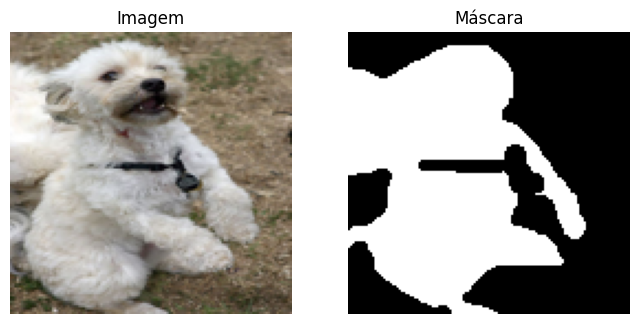

In [5]:
images, masks = next(iter(train_loader))

print("Imagem:", images.shape)
print("Máscara:", masks.shape)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(images[0].permute(1,2,0))
plt.title("Imagem")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(masks[0][0], cmap="gray")
plt.title("Máscara")
plt.axis("off")

plt.show()

In [6]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(DEVICE)

print("Modelo carregado!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Modelo carregado!


In [7]:
import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [8]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()

    running_loss = 0

    for images, masks in loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [9]:
EPOCHS = 10

for epoch in range(EPOCHS):
    loss = train_epoch(model, train_loader, optimizer, criterion)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {loss:.4f}")

Epoch 1/10 - Loss: 0.3998
Epoch 2/10 - Loss: 0.2272
Epoch 3/10 - Loss: 0.1766
Epoch 4/10 - Loss: 0.1550
Epoch 5/10 - Loss: 0.1331
Epoch 6/10 - Loss: 0.1139
Epoch 7/10 - Loss: 0.1039
Epoch 8/10 - Loss: 0.0971
Epoch 9/10 - Loss: 0.0955
Epoch 10/10 - Loss: 0.0900


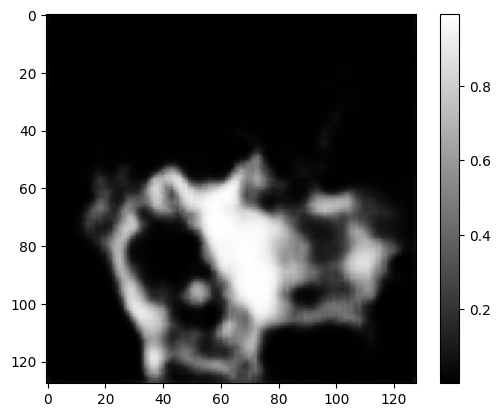

In [10]:
model.eval()

image, mask = test_dataset[0]

with torch.no_grad():

    pred = model(
        image.unsqueeze(0).to(DEVICE)
    )

    pred = torch.sigmoid(pred)

    pred = pred.cpu().squeeze().numpy()
    plt.imshow(pred, cmap="gray")
    plt.colorbar()


In [11]:
from torchmetrics.classification import BinaryJaccardIndex
from torchmetrics.classification import BinaryAccuracy

iou_metric = BinaryJaccardIndex().to(DEVICE)
acc_metric = BinaryAccuracy().to(DEVICE)

model.eval()

iou_metric.reset()
acc_metric.reset()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)

        outputs = torch.sigmoid(outputs)

        preds = (outputs > 0.5).float()

        iou_metric.update(preds, masks)
        acc_metric.update(preds, masks)

iou = iou_metric.compute().item()
acc = acc_metric.compute().item()

print(f"IoU: {iou:.4f}")
print(f"Acurácia: {acc:.4f}")

IoU: 0.7886
Acurácia: 0.9297


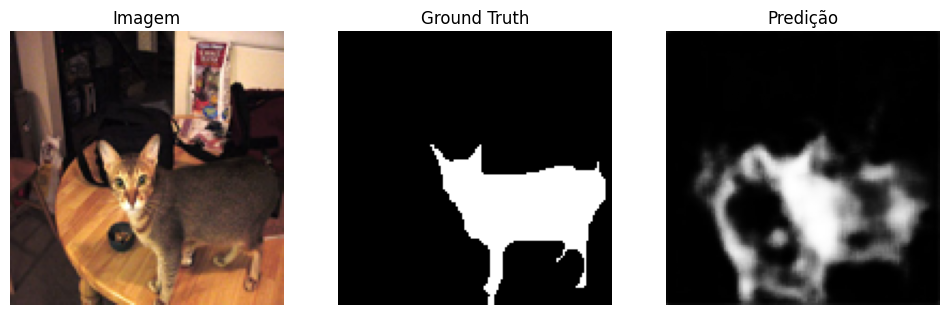

In [12]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image.permute(1,2,0))
plt.title("Imagem")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred, cmap="gray")
plt.title("Predição")
plt.axis("off")

plt.savefig("resultado_segmentacao.png", dpi=200, bbox_inches="tight")
plt.show()

In [13]:
torch.save(model.state_dict(), "unet_pet_segmentation.pth")

In [17]:
!pip install onnx onnxscript

In [18]:

dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

torch.onnx.export(
    model,
    dummy_input,
    "unet_pet_segmentation.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=11
)

print("Modelo ONNX exportado!")

W0607 14:25:44.920000 1542 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `Unet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Unet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/BaseConverter.h:64: adapter_lookup: Assertion `false`

[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Modelo ONNX exportado!


In [15]:
torch.save(model.state_dict(), "unet_pet_segmentation.pth")

with open("metricas.txt", "w") as f:
    f.write("IoU: 0.7903\n")
    f.write("Acurácia: 0.9304\n")


In [19]:
from google.colab import files

files.download("unet_pet_segmentation.pth")
files.download("unet_pet_segmentation.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>